
# **VAE$^2$** (VAEs for Human Values Analysis and Value Profile Generation)

---




# Data Loading and Preparation

In [41]:
# ==========================================
# ENVIRONMENT SETUP
# ==========================================
import os

# Auto-detect environment (Google Colab vs local)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_PATH = '/content/ESS11e04_1-subset.csv'
    PROCESSED_PATH = '/content/pvq_10valores.csv'
    OUTPUT_PATH = '/content/'
else:
    DATA_PATH = '../data/ESS11e04_1-subset.csv'
    PROCESSED_PATH = '../data/pvq_10valores.csv'
    OUTPUT_PATH = '../outputs/'
    os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"✅ Running in {'Google Colab' if IN_COLAB else 'local'} environment")
print(f"   Data path: {DATA_PATH}")

✅ Running in Google Colab environment
   Data path: /content/ESS11e04_1-subset.csv


In [42]:
# ==========================================
# 1. LIBRARY IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [43]:
# ==========================================
# 2. DATA LOADING AND CLEANING (FULL ESS DATASET)
# ==========================================
# === 1. Load data ===
df = pd.read_csv(DATA_PATH)

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# === 2. Define PVQ items ===
values_map = {
    "sdms": ["impfreea", "ipcrtiva"],
    "stmms": ["impdiffa", "ipadvnta"],
    "hems": ["impfuna", "ipgdtima"],
    "acms": ["ipsucesa", "ipshabta"],
    "poms": ["impricha", "iprspota"],
    "secms": ["impsafea", "ipstrgva"],
    "conms": ["ipbhprpa", "ipfrulea"],
    "trms": ["imptrada", "ipmodsta"],
    "bems": ["iphlppla", "iplylfra"],
    "unms": ["impenva", "ipeqopta", "ipudrsta"]
}

# Flat list of all raw items
cols_items = [col for cols in values_map.values() for col in cols]

# === 3. CLEANING ===
for col in cols_items:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[df[col] > 6, col] = np.nan

df_clean = df.dropna(subset=cols_items).copy()

# === 4. Compute the 10 aggregated value scores ===
cols_valores = ["sdms", "bems", "unms", "stmms", "hems",
                "acms", "poms", "secms", "conms", "trms"]

for val, cols in values_map.items():
    df_clean[val] = df_clean[cols].mean(axis=1)

# === 5. Ipsatization (applied over the 10 aggregated values) ===
df_clean["pvq_mean"] = df_clean[cols_valores].mean(axis=1)
for val in cols_valores:
    df_clean[val] = df_clean[val] - df_clean["pvq_mean"]

# === 6. Final selection ===
cols_final = ["cntry", "sdms", "bems", "unms", "stmms", "hems",
              "acms", "poms", "secms", "conms", "trms"]
cols_ms = ["sdms", "bems", "unms", "stmms", "hems",
           "acms", "poms", "secms", "conms", "trms"]

df_final = df_clean[cols_final]

# === 7. Save ===
df_final.to_csv(PROCESSED_PATH, index=False)

print(f"✅ Clean data ready. Number of individuals: {df_clean.shape[0]}")

X_raw = df_final[cols_valores].values
countries = df_final["cntry"].values

print(f"Data ready. Shape: {X_raw.shape}")

✅ Clean data ready. Number of individuals: 46158
Data ready. Shape: (46158, 10)


In [44]:
# ==========================================
# 2. LOADING PREPROCESSED DATA (ESS - 10 VALUES)
# ==========================================
print("Loading preprocessed dataset...")

# === 1. Load the clean, ipsatized CSV ===
df_final = pd.read_csv(PROCESSED_PATH)

# === 2. Define value columns ===
cols_ms = ["sdms", "bems", "unms", "stmms", "hems",
           "acms", "poms", "secms", "conms", "trms"]

# === 3. Extract matrices for PyTorch and Scikit-Learn ===
X_raw = df_final[cols_ms].values
countries = df_final["cntry"].values

print(f"✅ Data loaded successfully.")
print(f"Number of individuals: {X_raw.shape[0]}")
print(f"Shape of X_raw: {X_raw.shape}")
print(f"Unique countries in dataset: {len(np.unique(countries))}")

Loading preprocessed dataset...
✅ Data loaded successfully.
Number of individuals: 46158
Shape of X_raw: (46158, 10)
Unique countries in dataset: 30


In [ ]:
df_final.head()

,cntry,sdms,bems,unms,stmms,hems,acms,poms,secms,conms,trms
0,AT,-0.100000,-0.600000,-0.60,1.900000,-0.100000,-0.100000,0.900000,-0.600000,-0.600000,-0.100000
1,AT,-0.766667,-1.766667,-1.10,1.233333,-0.766667,1.233333,1.233333,0.233333,0.233333,0.233333
2,AT,-0.950000,-1.450000,-1.45,1.550000,0.050000,0.550000,1.050000,-0.450000,0.550000,0.550000
3,AT,-0.233333,-0.733333,-0.40,1.266667,0.266667,0.266667,0.766667,-0.733333,0.266667,-0.733333
4,AT,-0.100000,-0.600000,-0.60,1.400000,-0.100000,-0.600000,0.400000,-0.600000,0.900000,-0.100000


In [15]:
# ==========================================
# 3. PREPROCESSING AND SCALING
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Definición del modelo

In [16]:
# ==========================================
# 4. VAE ARCHITECTURE IN PYTORCH
# ==========================================
class VAE(nn.Module):
    def __init__(self, input_dim=10, latent_dim=2):
        super(VAE, self).__init__()

        # --- ENCODER ---
        self.fc1 = nn.Linear(input_dim, 64)
        # The network bifurcates to output the mean (mu) and log-variance (logvar)
        self.fc21 = nn.Linear(64, latent_dim) # mu
        self.fc22 = nn.Linear(64, latent_dim) # logvar

        # --- DECODER ---
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        # Reparameterization trick to allow gradient computation through stochastic sampling
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return self.fc4(h)

    def forward(self, x):
        # Full forward pass: input data -> reconstruction + latent parameters
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [19]:
# ==========================================
# 5. TRAINING: CALIBRATED STANDARD VAE (50K)
# ==========================================
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

def train_vae(X, epochs=50, latent_dim=5):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)

    # 1. LARGE BATCH SIZE (1024)
    loader = DataLoader(dataset, batch_size=1024, shuffle=True)

    model = VAE(input_dim=10, latent_dim=latent_dim)

    # 2. HIGH LEARNING RATE (2e-3): large batches require bolder gradient steps
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

    history_recon = []
    history_kl = []

    # 3. BETA-ANNEALING STRATEGY: gradual KL warmup to preserve latent structure
    max_beta = 0.15
    warmup_epochs = 30  # Progressive warmup to avoid destroying structure abruptly

    for epoch in range(epochs):
        total_recon, total_kl = 0, 0
        beta = min(max_beta, (epoch / warmup_epochs) * max_beta)

        for batch in loader:
            x = batch[0]
            optimizer.zero_grad()
            recon, mu, logvar = model(x)

            # Standard reconstruction and KL losses
            recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
            KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

            loss = recon_loss + beta * KL

            loss.backward()
            optimizer.step()

            total_recon += recon_loss.item()
            total_kl += KL.item()

        avg_recon = total_recon / len(loader)
        avg_kl = total_kl / len(loader)

        history_recon.append(avg_recon)
        history_kl.append(avg_kl)

        # Print progress every 5 epochs
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:2d} | "
                f"Beta: {beta:.4f} | "
                f"Recon: {avg_recon:.4f} | "
                f"KL: {avg_kl:.4f}"
            )

    # Convergence plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(9, 4))
    plt.plot(range(1, epochs + 1), history_recon, label='Recon Loss', color='#1f77b4', linewidth=2)
    plt.plot(range(1, epochs + 1), history_kl, label='KL Divergence', color='#ff7f0e', linewidth=2)
    plt.title('VAE Training Dynamics', fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(X_tensor)
        Z = mu.numpy()

    return model, Z

# training

Training Model...
Epoch  0 | Beta: 0.0000 | Recon: 7.6941 | KL: 2.5350
Epoch  5 | Beta: 0.0250 | Recon: 2.6051 | KL: 13.5723
Epoch 10 | Beta: 0.0500 | Recon: 2.5231 | KL: 10.5654
Epoch 15 | Beta: 0.0750 | Recon: 2.5088 | KL: 9.3330
Epoch 20 | Beta: 0.1000 | Recon: 2.5201 | KL: 8.6208
Epoch 25 | Beta: 0.1250 | Recon: 2.5557 | KL: 8.0981
Epoch 30 | Beta: 0.1500 | Recon: 2.5625 | KL: 7.6578
Epoch 35 | Beta: 0.1500 | Recon: 2.5470 | KL: 7.7030
Epoch 40 | Beta: 0.1500 | Recon: 2.5131 | KL: 7.7441
Epoch 45 | Beta: 0.1500 | Recon: 2.4859 | KL: 7.7754
Epoch 49 | Beta: 0.1500 | Recon: 2.4647 | KL: 7.8340


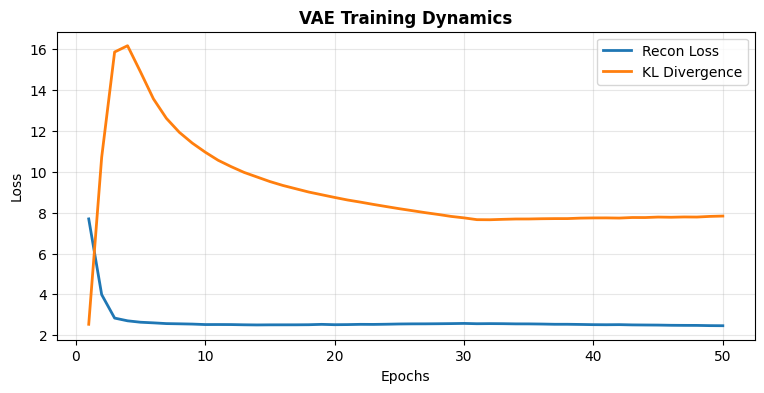

In [20]:
# ==========================================
# 6. MODEL TRAINING
# ==========================================
print("Training Model...")
model, Z = train_vae(X, epochs=50, latent_dim=5)

# Latent Space Analysis

## Unsupervised Discovery of Schwartz’s Axes

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ==========================================
# PCA ANALYSIS OF THE LATENT SPACE
# ==========================================
def evaluar_espacio_latente(Z_latente, df_original=df_clean, cols_ms=cols_ms, titulo="Circumplex in PCA of the Latent Space"):
    """
    Takes the latent space (Z) extracted from real individuals, applies PCA,
    and correlates the latent dimensions with the original values to visualize
    the Schwartz circumplex structure.
    """
    print(f"\n Generando gráfica de cargas factoriales para: Circumplex en PCA del espacio latente")

    # 1. Work on a copy to avoid modifying the original dataset
    df_temp = df_original.copy()

    # 2. Apply PCA to the latent dimensions
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z_latente)
    var_explicada = pca.explained_variance_ratio_ * 100

    df_temp['PC1'] = Z_pca[:, 0]
    df_temp['PC2'] = Z_pca[:, 1]

    # 3. Value name mapping for publication-ready labels
    value_names = {
        "sdms": "Self-Direction", "bems": "Benevolence", "unms": "Universalism",
        "stmms": "Stimulation", "hems": "Hedonism", "acms": "Achievement",
        "poms": "Power", "secms": "Security", "conms": "Conformity", "trms": "Tradition"
    }

    # 4. Compute correlations with principal components
    correlations = []
    for col in cols_ms:
        r1 = np.corrcoef(df_temp['PC1'], df_temp[col])[0, 1]
        r2 = np.corrcoef(df_temp['PC2'], df_temp[col])[0, 1]
        correlations.append({
            "Value": value_names.get(col, col),
            "Corr_PC1": r1,
            "Corr_PC2": r2
        })

    df_corr = pd.DataFrame(correlations)

    # 5. Visualization
    plt.figure(figsize=(9, 8))
    sns.scatterplot(x='Corr_PC1', y='Corr_PC2', data=df_corr, s=150, color='darkblue', edgecolor='white')

    for i, row in df_corr.iterrows():
        plt.annotate(
            row['Value'],
            (row['Corr_PC1'], row['Corr_PC2']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontweight='bold'
        )

    plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.6)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)

    plt.title(titulo, fontweight='bold', fontsize=14)
    plt.xlabel(f"Correlation with Latent PC1 ({var_explicada[0]:.1f}% Explained Variance)", fontsize=12)
    plt.ylabel(f"Correlation with Latent PC2 ({var_explicada[1]:.1f}% Explained Variance)", fontsize=12)
    plt.grid(alpha=0.2)
    plt.show()

    return df_corr, pca


Generando gráfica de cargas factoriales para: Circumplex en PCA del espacio latente


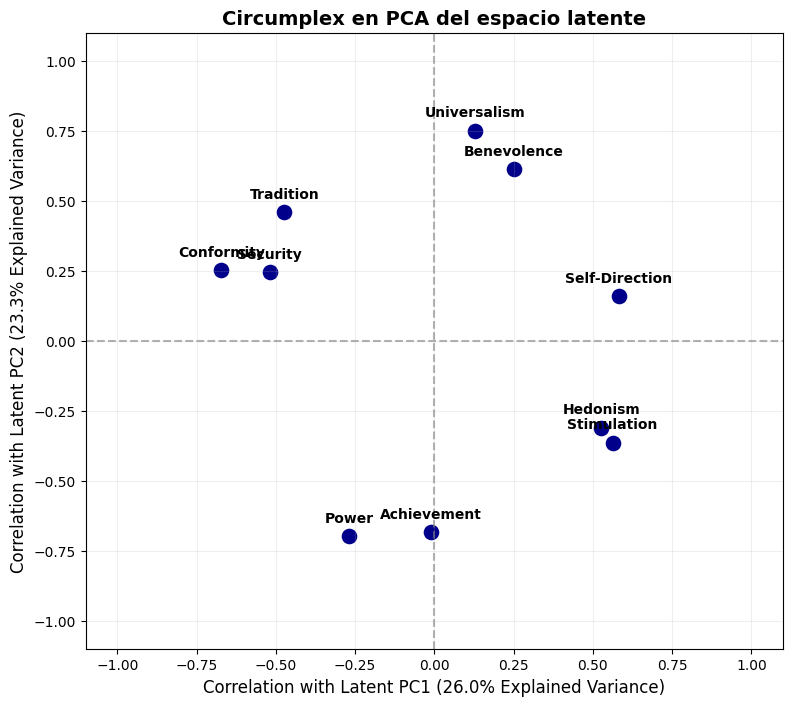

(            Valor  Corr_PC1  Corr_PC2
 0  Self-Direction  0.582295  0.159632
 1     Benevolence  0.250143  0.612101
 2    Universalism  0.126978  0.750680
 3     Stimulation  0.561768 -0.363778
 4        Hedonism  0.525890 -0.310458
 5     Achievement -0.011344 -0.684151
 6           Power -0.269947 -0.698778
 7        Security -0.519624  0.244415
 8      Conformity -0.671895  0.251193
 9       Tradition -0.473085  0.458835,
 PCA(n_components=2))

In [ ]:

evaluar_espacio_latente(Z, titulo="Circumplex en PCA del espacio latente")

## Psychological Trajectories via Interpolation

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def generar_grafico_interpolacion(modelo_vae, scaler, X_real, cols_ms, steps=10):
    """
    Takes two opposing profiles, interpolates in the latent space,
    and plots the value transition trajectory.
    """
    modelo_vae.eval()

    # Value name mapping
    value_names = {
        "sdms": "Self-Direction", "bems": "Benevolence", "unms": "Universalism",
        "stmms": "Stimulation", "hems": "Hedonism", "acms": "Achievement",
        "poms": "Power", "secms": "Security", "conms": "Conformity", "trms": "Tradition"
    }

    # 1. FIND TWO EXTREME PROFILES (Tradition vs Hedonism)
    idx_trad = cols_ms.index('trms')
    idx_hedo = cols_ms.index('hems')

    idx_indiv_A = np.argmax(X_real[:, idx_trad])
    idx_indiv_B = np.argmax(X_real[:, idx_hedo])

    tensor_A = torch.tensor(X_real[idx_indiv_A]).float().unsqueeze(0)
    tensor_B = torch.tensor(X_real[idx_indiv_B]).float().unsqueeze(0)

    with torch.no_grad():
        # 2. OBTAIN LATENT COORDINATES
        mu_A, _ = modelo_vae.encode(tensor_A)
        mu_B, _ = modelo_vae.encode(tensor_B)

        # 3. BUILD LINEAR INTERPOLATION PATH
        alphas = np.linspace(0, 1, steps)
        z_interp = []
        for alpha in alphas:
            # Linear interpolation formula: Point_A * (1 - alpha) + Point_B * alpha
            z_step = mu_A * (1 - alpha) + mu_B * alpha
            z_interp.append(z_step)

        z_interp = torch.cat(z_interp, dim=0)

        # 4. DECODE INTERMEDIATE SYNTHETIC PROFILES
        x_interp_scaled = modelo_vae.decode(z_interp).cpu().numpy()

    # 5. INVERSE TRANSFORM (StandardScaler + Re-ipsatization)
    x_interp_real = scaler.inverse_transform(x_interp_scaled)
    x_interp_ips = x_interp_real - x_interp_real.mean(axis=1, keepdims=True)

    # ==========================================
    # 6. PLOT
    # ==========================================
    df_plot = pd.DataFrame(x_interp_ips, columns=cols_ms)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    colores = sns.color_palette("husl", len(cols_ms))

    for i, col in enumerate(cols_ms):
        # Highlight the two main variables with thicker lines
        linewidth = 3.5 if col in ['trms', 'hems'] else 1.5
        alpha = 1.0 if col in ['trms', 'hems'] else 0.4

        nombre_completo = value_names.get(col, col.upper())

        plt.plot(alphas, df_plot[col], marker='o', label=nombre_completo,
                 linewidth=linewidth, color=colores[i], alpha=alpha)

    plt.title('Latent Space Trajectory: Continuity of Schwartz Values', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Interpolation Step (From Profile A to Profile B)', fontsize=12)
    plt.ylabel('Relative Value Priority', fontsize=12)

    y_min = df_plot.values.min()
    y_max = df_plot.values.max()
    plt.ylim(-2.5, 4.5)

    plt.xticks(ticks=[0, 0.5, 1], labels=['Profile A\n(High Tradition)', 'Hybrid Profile', 'Profile B\n(High Hedonism)'])

    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title="Schwartz Values", fontsize=8)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

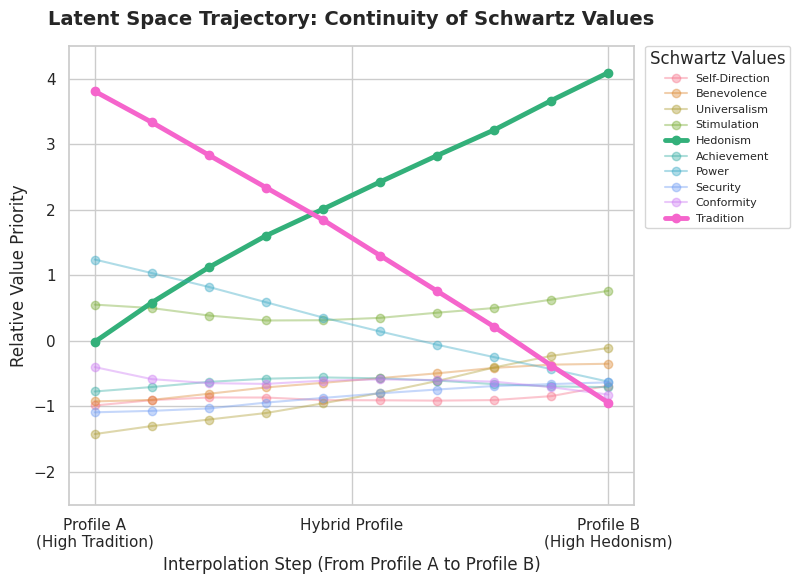

In [ ]:
# Run interpolation (pass normalized real data in X)
generar_grafico_interpolacion(model, scaler, X, cols_ms, steps=10)

## Targeted Sampling

In [28]:
def generar_grafico_targeted_sampling(modelo_vae, scaler, X_real, cols_ms, n_samples=200, sigma=0.3):
    """
    Visualizes targeted sampling in the latent space:
    - Real profiles in gray
    - Seed profile in red
    - Generated samples around the seed in blue
    """
    modelo_vae.eval()

    # 1. SELECT A RARE SEED PROFILE
    # Find an individual with high Tradition AND high Hedonism (contradictory profile)
    idx_trad = cols_ms.index('trms')
    idx_hedo = cols_ms.index('hems')

    # Combined score: high tradition + high hedonism
    score_raro = X_real[:, idx_trad] + X_real[:, idx_hedo]
    idx_semilla = np.argmax(score_raro)

    tensor_semilla = torch.tensor(X_real[idx_semilla]).float().unsqueeze(0)

    with torch.no_grad():
        # 2. OBTAIN LATENT COORDINATE OF THE SEED PROFILE
        mu_semilla, _ = modelo_vae.encode(tensor_semilla)

        # 3. GENERATE SAMPLES AROUND THE SEED PROFILE
        epsilon = torch.randn(n_samples, mu_semilla.shape[1]) * sigma
        z_samples = mu_semilla + epsilon

        # 4. DECODE
        x_samples_scaled = modelo_vae.decode(z_samples).cpu().numpy()

        # 5. OBTAIN LATENT COORDINATES OF ALL REAL PROFILES
        X_tensor = torch.tensor(X_real).float()
        mu_real, _ = modelo_vae.encode(X_tensor)
        mu_real = mu_real.cpu().numpy()

        # 6. LATENT COORDINATES OF THE SYNTHETIC SAMPLES
        mu_samples, _ = modelo_vae.encode(
            torch.tensor(x_samples_scaled).float()
        )
        mu_samples = mu_samples.cpu().numpy()
        mu_semilla_np = mu_semilla.cpu().numpy()

    # 7. PCA ON THE LATENT SPACE
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca.fit(mu_real)

    real_2d = pca.transform(mu_real)
    semilla_2d = pca.transform(mu_semilla_np)
    samples_2d = pca.transform(mu_samples)

    # 8. PLOT
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    plt.scatter(real_2d[:, 0], real_2d[:, 1],
                c='lightgray', alpha=0.3, s=10, label='Empirical profiles')
    plt.scatter(samples_2d[:, 0], samples_2d[:, 1],
                c='steelblue', alpha=0.6, s=20, label=f'Synthetic samples (σ={sigma})')
    plt.scatter(semilla_2d[:, 0], semilla_2d[:, 1],
                c='red', s=150, zorder=5, label='Seed profile', marker='*')

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=12)
    plt.title('Targeted Sampling in the Latent Space', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # 9. PRINT SEED PROFILE
    x_semilla_original = scaler.inverse_transform(X_real[idx_semilla].reshape(1, -1))
    df_semilla = pd.DataFrame(x_semilla_original, columns=cols_ms)
    print("\nSeed profile (ipsatized scale):")
    print(df_semilla.round(3))

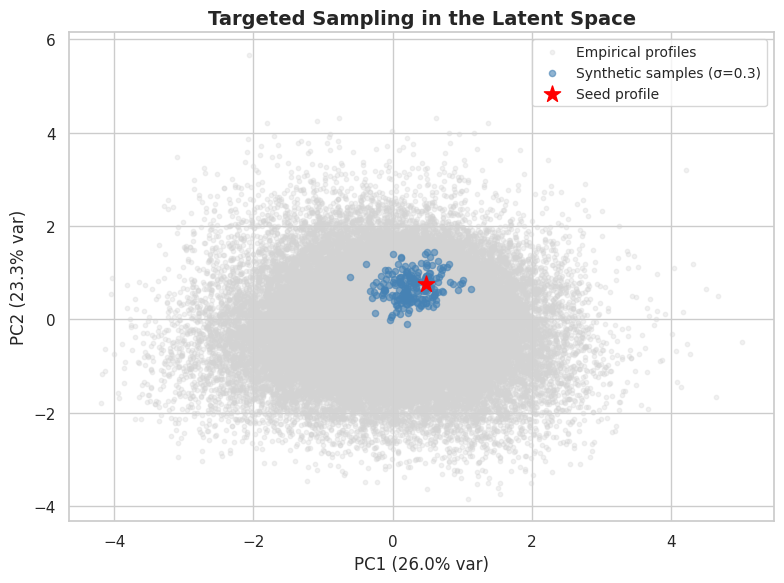


Seed profile (ipsatized scale):
   sdms  bems  unms  stmms  hems  acms  poms  secms  conms  trms
0  -1.0   0.0  -1.0    1.5   2.5  -2.0   0.0   -2.0   -1.0   3.0


In [ ]:

generar_grafico_targeted_sampling(modelo_vae=model, scaler=scaler,
                                   X_real=X, cols_ms=cols_ms)

# Validation of Synthetic Generation

In [30]:
# ==========================================
# SYNTHETIC POPULATION GENERATION
# ==========================================
def generar_poblacion(modelo, scaler=scaler, latent_dim=5, n_eval=5000):
    """
    Generates synthetic individuals and returns them in their original
    ipsatized scale.
    """
    print(f"Generating synthetic population...")

    modelo.eval()

    # 1. Sample from the latent space
    z_random = torch.randn(n_eval, latent_dim).float()

    # 2. Decode (output is in StandardScaled space)
    with torch.no_grad():
        synthetic_scaled = modelo.decode(z_random).cpu().numpy()

    # 3. Inverse transform back to original Schwartz scale
    synthetic_original = scaler.inverse_transform(synthetic_scaled)

    # Schwartz value columns
    cols_ms = ["sdms", "bems", "unms", "stmms", "hems", "acms", "poms", "secms", "conms", "trms"]

    # 4. Build DataFrame in human-scale values
    df_generado = pd.DataFrame(synthetic_original, columns=cols_ms)
    X_generado = df_generado.values

    print(f"✅ Successfully generated {X_generado.shape[0]} synthetic individuals.\n")
    return df_generado, X_generado

In [31]:
df_synt, X_synt=generar_poblacion(model)



Generating synthetic population...
✅ Successfully generated 5000 synthetic individuals.



In [32]:
df_synt.head()

,sdms,bems,unms,stmms,hems,acms,poms,secms,conms,trms
0,-1.113884,-0.640819,-0.625377,-1.003317,-0.817679,0.003527,0.920662,1.146317,1.088344,1.033624
1,0.602019,0.294650,-0.406143,1.040887,0.631573,-0.508869,-0.329417,-0.895548,-0.275987,-0.161317
2,-0.718858,-0.424789,-0.348354,0.319415,-0.292233,-0.384514,0.356599,-0.833237,1.379690,0.958867
3,-0.500115,-1.035361,-0.900162,0.744969,0.611534,0.482641,1.321341,-0.510215,-0.318711,0.088831
4,-0.780105,-0.842219,-0.654215,0.519655,0.629263,-0.200350,0.577004,-0.155538,-0.167756,1.049789


In [33]:
# ==========================================
# REAL DATA SUBSET (5K)
# ==========================================

n_eval = 5000
print("Creating real data subset...")

idx_real = np.random.choice(X.shape[0], n_eval, replace=False)
X_real_eval = X[idx_real]

# Inverse transform to ipsatized scale (same scale as generated synthetic profiles)
X_real_eval_original = scaler.inverse_transform(X_real_eval)

print(f"Real eval shape: {X_real_eval_original.shape}")

df_real_eval = pd.DataFrame(X_real_eval_original, columns=cols_ms)

Creating real data subset...
Real eval shape: (5000, 10)


## Generalization Test


--- Ejecutando Test de Memorización ---


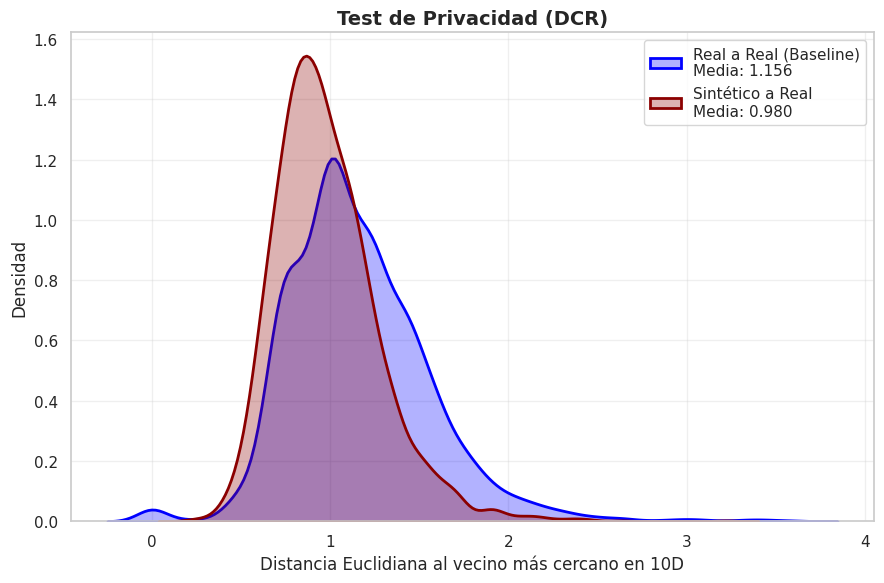


=== VEREDICTO DE PRIVACIDAD ===
Distancia media Real-Real (Variabilidad natural): 1.1556
Distancia media Sintético-Real (Novedad de la IA): 0.9796
Individuos clonados exactamente (Plagios):         0 (0.00%)

Ratio de distancia (Sintético/Real): 0.85 (Lo ideal es que sea cercano a 1.0)
✅ ÉXITO: El modelo no plagia. Genera diversidad idéntica a la variación natural de la población.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

# =========================================================
# GENERALIZATION TEST: Distance to Closest Record (DCR)
# =========================================================
def evaluar_privacidad_dcr(df_real, df_synth, cols_ms, titulo="Test de Privacidad (DCR)"):
    print(f"\n--- Ejecutando Test de Memorización ---")

    X_real = df_real[cols_ms].values
    X_synth = df_synth[cols_ms].values

    # 1. Split real data into two halves (database vs control sample)
    # This establishes a baseline for the natural distance between two random real individuals
    mitad = len(X_real) // 2
    X_real_db = X_real[:mitad]
    X_real_control = X_real[mitad:]

    # Match synthetic sample size to control for fair comparison
    X_synth_sample = X_synth[:len(X_real_control)]

    # 2. Fit nearest neighbor search on the real database
    nn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='euclidean')
    nn.fit(X_real_db)

    # 3. Find closest real neighbor for each SYNTHETIC profile
    distancias_synth, _ = nn.kneighbors(X_synth_sample)

    # 4. Find closest real neighbor for each REAL control profile (baseline)
    distancias_real, _ = nn.kneighbors(X_real_control)

    # Flatten arrays
    distancias_synth = distancias_synth.flatten()
    distancias_real = distancias_real.flatten()

    # 5. Detect exact copies (near-zero distance threshold)
    plagios = np.sum(distancias_synth < 1e-5)
    porcentaje_plagio = (plagios / len(distancias_synth)) * 100

    # 6. Visualization
    plt.figure(figsize=(9, 6))

    sns.kdeplot(distancias_real, color='blue', fill=True, alpha=0.3, linewidth=2,
                label=f'Real a Real (Baseline)\nMedia: {distancias_real.mean():.3f}')
    sns.kdeplot(distancias_synth, color='darkred', fill=True, alpha=0.3, linewidth=2,
                label=f'Sintético a Real\nMedia: {distancias_synth.mean():.3f}')

    plt.title(titulo, fontweight='bold', fontsize=14)
    plt.xlabel('Distancia Euclidiana al vecino más cercano en 10D')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 7. Veredicto
    print("\n=== VEREDICTO DE PRIVACIDAD ===")
    print(f"Distancia media Real-Real (Variabilidad natural): {distancias_real.mean():.4f}")
    print(f"Distancia media Sintético-Real (Novedad de la IA): {distancias_synth.mean():.4f}")
    print(f"Individuos clonados exactamente (Plagios):         {plagios} ({porcentaje_plagio:.2f}%)")

    ratio = distancias_synth.mean() / distancias_real.mean()
    print(f"\nRatio de distancia (Sintético/Real): {ratio:.2f} (Lo ideal es que sea cercano a 1.0)")

    if ratio < 0.8:
        print("⚠️ ALERTA: La distancia sintética es sospechosamente baja. Hay sobreajuste (memorización).")
    elif plagios > 0:
        print("⚠️ ALERTA: Se han detectado clones exactos. Rompe la privacidad.")
    else:
        print("✅ ÉXITO: El modelo no plagia. Genera diversidad idéntica a la variación natural de la población.")

# Run generalization test
evaluar_privacidad_dcr(df_real_eval, df_synt, cols_ms)

## 1. Statistical Fidelity

In [35]:
from scipy.stats import wasserstein_distance, ks_2samp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================
# 1. UNIVARIATE FIDELITY (1D DISTRIBUTIONS)
# =========================================================
def evaluar_fidelidad_univariante(df_real, df_synth, cols_ms):
    """
    Compares individual distributions (means, variances, Wasserstein, KS)
    between real and synthetic data, and plots KDE density curves.
    """
    print("=== MÉTRICAS UNIVARIANTES ===")
    metrics_1d = []

    for col in cols_ms:
        real = df_real[col]
        synth = df_synth[col]

        wd = wasserstein_distance(real, synth)
        ks_stat, _ = ks_2samp(real, synth)
        mean_diff = synth.mean() - real.mean()
        var_diff = synth.var() - real.var()

        metrics_1d.append({
            'Valor': col,
            'Wasserstein': wd,
            'KS_Stat': ks_stat,
            'Mean_Diff': mean_diff,
            'Var_Diff': var_diff
        })

    df_metrics_1d = pd.DataFrame(metrics_1d)

    print(df_metrics_1d.round(4))
    print(f"\nWasserstein medio: {df_metrics_1d['Wasserstein'].mean():.4f}")
    print(f"KS medio: {df_metrics_1d['KS_Stat'].mean():.4f}")
    print(f"|Media diff| media: {df_metrics_1d['Mean_Diff'].abs().mean():.4f}")
    print(f"|Var diff| media: {df_metrics_1d['Var_Diff'].abs().mean():.4f}\n")

    # KDE density plots
    n_cols = 5
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
    axes = axes.flatten()

    for i, col in enumerate(cols_ms):
        ax = axes[i]
        sns.kdeplot(df_real[col], ax=ax, label='Real', color='blue', fill=True, alpha=0.3)
        sns.kdeplot(df_synth[col], ax=ax, label='Sintético', color='darkred', fill=True, alpha=0.3)
        ax.set_title(col)
        if i == 0:
            ax.legend(fontsize=8)

    plt.suptitle("Comparación de Densidades (KDE): Real vs Sintético", fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df_metrics_1d


# =========================================================
# 2. BIVARIATE FIDELITY (CORRELATION MATRICES)
# =========================================================
def evaluar_fidelidad_correlaciones(df_real, df_synth, cols_ms):
    """
    Compares the correlation matrices of real and synthetic datasets,
    computing MAE, Frobenius norm, Pearson similarity, and generating
    heatmaps and scatter plots.
    """
    print("\n=== MÉTRICAS DE CORRELACIÓN ===")

    corr_real = df_real[cols_ms].corr()
    corr_synth = df_synth[cols_ms].corr()
    corr_diff = corr_real - corr_synth

    mae_corr = np.abs(corr_diff.values).mean()
    print(f"MAE de correlaciones: {mae_corr:.4f}")

    n_features = len(cols_ms)
    max_frobenius = np.sqrt(n_features * n_features * (2**2))

    frobenius_raw = np.linalg.norm(corr_diff.values, 'fro')
    frobenius_norm = frobenius_raw / max_frobenius

    print(f"Norma de Frobenius normalizada: {frobenius_norm:.4f}  (raw: {frobenius_raw:.2f})")

    # Pearson similarity between correlation matrices
    corr_real_flat = corr_real.values.flatten()
    corr_synth_flat = corr_synth.values.flatten()
    pearson_sim = np.corrcoef(corr_real_flat, corr_synth_flat)[0, 1]
    print(f"Pearson similarity entre matrices de correlación: {pearson_sim:.4f}")

    # 1. Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, square=True,
                cbar_kws={'label': 'Correlación'})
    axes[0].set_title("Matriz Correlación REAL")

    sns.heatmap(corr_synth, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, square=True,
                cbar_kws={'label': 'Correlación'})
    axes[1].set_title("Matriz Correlación SINTÉTICA")

    sns.heatmap(corr_diff, ax=axes[2], cmap='PRGn', vmin=-0.5, vmax=0.5, square=True,
                cbar_kws={'label': 'Diferencia'})
    axes[2].set_title(f"Diferencia (MAE={mae_corr:.3f}, Frob={frobenius_norm:.3f})")

    plt.tight_layout()
    plt.show()

    # 2. Correlation scatter plot
    idx_upper = np.triu_indices_from(corr_real, k=1)
    real_vals = corr_real.values[idx_upper]
    synth_vals = corr_synth.values[idx_upper]

    plt.figure(figsize=(6, 6))
    plt.scatter(real_vals, synth_vals, alpha=0.6, color='darkred', edgecolors='k', linewidth=0.5)
    plt.plot([-1, 1], [-1, 1], 'gray', linestyle='--')
    plt.xlabel('Correlación Real')
    plt.ylabel('Correlación Sintética')
    plt.title('Preservación de Correlaciones (R2)', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.tight_layout()
    plt.show()

    return mae_corr, frobenius_norm, pearson_sim


# =========================================================
# 3. MASTER FUNCTION: GLOBAL FIDELITY EVALUATION
# =========================================================
def evaluar_fidelidad(df_real, df_synth, cols_ms=cols_ms, titulo_informe="Reporte de Fidelidad del Modelo"):
    """
    Runs the full statistical evaluation pipeline (univariate + bivariate)
    and returns a dictionary with all metrics for further analysis.
    """
    print("=" * 60)
    print(f"🚀 INICIANDO: {titulo_informe.upper()}")
    print("=" * 60)

    # 1. Univariate evaluation
    df_metricas_1d = evaluar_fidelidad_univariante(df_real, df_synth, cols_ms)

    # 2. Bivariate evaluation
    mae, frob, pearson_sim = evaluar_fidelidad_correlaciones(df_real, df_synth, cols_ms)

    # 3. Package results
    resultados = {
        'metricas_1d': df_metricas_1d,
        'wasserstein_medio': df_metricas_1d['Wasserstein'].mean(),
        'ks_medio': df_metricas_1d['KS_Stat'].mean(),
        'mae_correlaciones': mae,
        'frobenius_norm': frob,
        'pearson_sim': pearson_sim
    }

    print("=" * 60)
    print("✅ EVALUACIÓN COMPLETADA. Resumen Global:")
    print(f"   - Diferencia de distribución (Wasserstein medio): {resultados['wasserstein_medio']:.4f}")
    print(f"   - Error absoluto en correlaciones (MAE): {resultados['mae_correlaciones']:.4f}")
    print(f"   - Deformación topológica (Frobenius): {resultados['frobenius_norm']:.4f}")
    print("=" * 60)

    return resultados

🚀 INICIANDO: REPORTE DE FIDELIDAD DEL MODELO
=== MÉTRICAS UNIVARIANTES ===
   Valor  Wasserstein  KS_Stat  Mean_Diff  Var_Diff
0   sdms       0.1255   0.1004     0.0127   -0.0952
1   bems       0.1038   0.0730    -0.0035   -0.1340
2   unms       0.1135   0.0722    -0.0172   -0.1643
3  stmms       0.1768   0.0814     0.0384   -0.3659
4   hems       0.1718   0.0804    -0.0554   -0.2598
5   acms       0.1087   0.0718     0.0056   -0.2091
6   poms       0.1105   0.0606    -0.0304   -0.2137
7  secms       0.0790   0.0584     0.0153   -0.1125
8  conms       0.0763   0.0430     0.0123   -0.1551
9   trms       0.1190   0.0740     0.0272   -0.2000

Wasserstein medio: 0.1185
KS medio: 0.0715
|Media diff| media: 0.0218
|Var diff| media: 0.1909



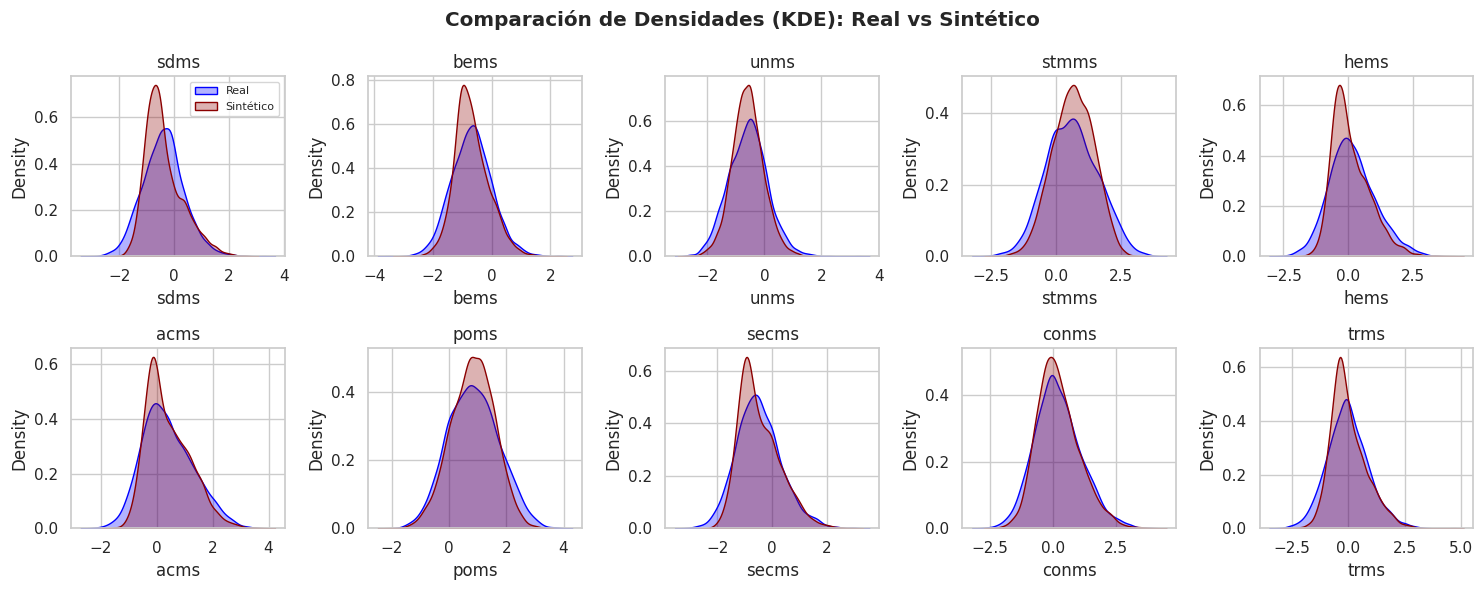


=== MÉTRICAS DE CORRELACIÓN ===
MAE de correlaciones: 0.0828
Norma de Frobenius normalizada: 0.0532  (raw: 1.06)
Pearson similarity entre matrices de correlación: 0.9743


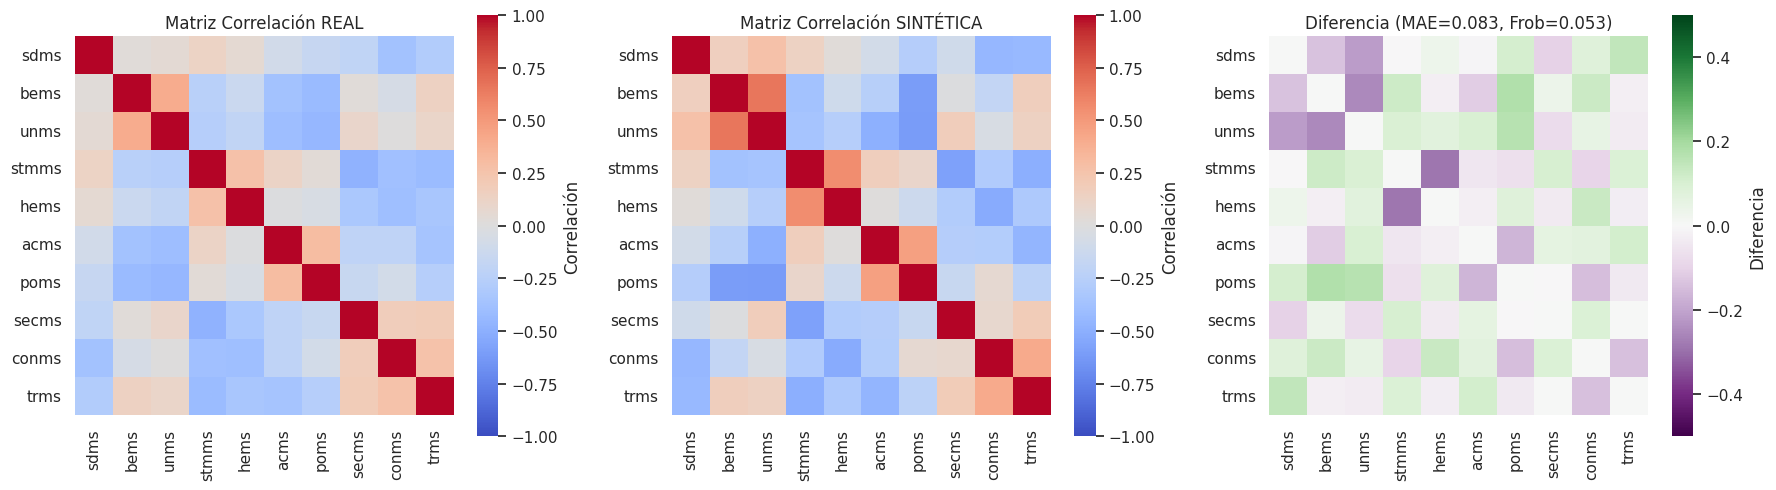

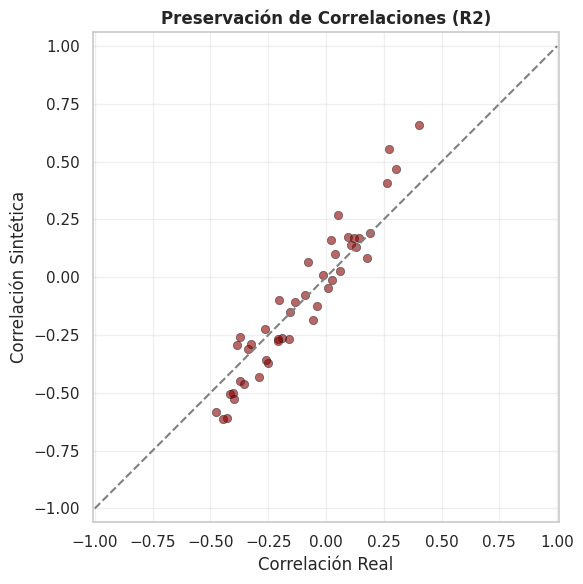

✅ EVALUACIÓN COMPLETADA. Resumen Global:
   - Diferencia de distribución (Wasserstein medio): 0.1185
   - Error absoluto en correlaciones (MAE): 0.0828
   - Deformación topológica (Frobenius): 0.0532


{'metricas_1d':    Valor  Wasserstein  KS_Stat  Mean_Diff  Var_Diff
 0   sdms     0.125505   0.1004   0.012664 -0.095205
 1   bems     0.103812   0.0730  -0.003547 -0.134017
 2   unms     0.113539   0.0722  -0.017218 -0.164277
 3  stmms     0.176773   0.0814   0.038409 -0.365897
 4   hems     0.171834   0.0804  -0.055384 -0.259751
 5   acms     0.108685   0.0718   0.005576 -0.209055
 6   poms     0.110534   0.0606  -0.030442 -0.213688
 7  secms     0.079008   0.0584   0.015348 -0.112479
 8  conms     0.076289   0.0430   0.012296 -0.155090
 9   trms     0.119048   0.0740   0.027241 -0.199990,
 'wasserstein_medio': np.float64(0.11850259729424276),
 'ks_medio': np.float64(0.07152),
 'mae_correlaciones': np.float64(0.0827766293065901),
 'frobenius_norm': np.float64(0.053161550698081664),
 'pearson_sim': np.float64(0.9742819944715199)}

In [ ]:
evaluar_fidelidad(df_real_eval, df_synt, titulo_informe="Reporte de Fidelidad del Modelo")

In [37]:
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np

# =========================================================
# 3. MAXIMUM MEAN DISCREPANCY (MMD)
# =========================================================
def evaluar_mmd(df_real, df_synth, cols_ms):
    """
    Computes MMD with an RBF kernel on the provided matrices.
    Assumes DataFrames are already correctly subsampled by the user.
    """
    print(f"\n--- Calculando MMD sobre {len(df_real)} muestras reales y {len(df_synth)} sintéticas ---")

    # Extract numerical matrices
    X_real = df_real[cols_ms].values
    X_synth = df_synth[cols_ms].values

    # Practical rule for gamma: 1 / number of features (dimensions)
    gamma = 1.0 / X_real.shape[1]

    # Compute kernel matrices
    Kxx = rbf_kernel(X_real, X_real, gamma=gamma)
    Kyy = rbf_kernel(X_synth, X_synth, gamma=gamma)
    Kxy = rbf_kernel(X_real, X_synth, gamma=gamma)

    # Empirical MMD formula
    mmd_value = Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

    print(f"✅ MMD (RBF Kernel): {mmd_value:.6f}")

    return mmd_value

In [ ]:

evaluar_mmd(df_real_eval, df_synt, cols_ms)


--- Calculando MMD sobre 5000 muestras reales y 5000 sintéticas ---
✅ MMD (RBF Kernel): 0.009966


np.float64(0.009966418358152151)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.neighbors import NearestNeighbors

def test_fidelidad_estado_del_arte(df_real, df_synth, cols):
    print("🚀 INICIANDO TEST DE FIDELIDAD (Métricas 2026)\n" + "="*50)

    # Extract values and ensure equal sample size for fairness
    n_samples = min(len(df_real), len(df_synth))
    X_real = df_real[cols].sample(n_samples, random_state=42).values
    X_synth = df_synth[cols].sample(n_samples, random_state=42).values

    # ==========================================
    # 1. LOW-DENSITY: 1-Way Marginals (KS-Statistic)
    # ==========================================
    # KS statistic measures the maximum distance between two distributions.
    # We invert it (1 - KS) so that 1.0 represents perfect match.
    ks_scores = []
    for i in range(len(cols)):
        stat, _ = ks_2samp(X_real[:, i], X_synth[:, i])
        ks_scores.append(1 - stat)

    score_marginal = np.mean(ks_scores)
    print(f"📊 Low-Density (KS-Statistic Medio): {score_marginal:.4f} (Ideal: > 0.90)")

    # ==========================================
    # 2. HIGH-DENSITY: Precision & Recall (Nearest Neighbors)
    # ==========================================
    # Compute the "radius" of the real space using the 5th nearest neighbor
    nn_real = NearestNeighbors(n_neighbors=5).fit(X_real)
    radios_reales, _ = nn_real.kneighbors(X_real)
    umbral_real = np.percentile(radios_reales[:, -1], 95)  # 95% of real mass

    # Compute the "radius" of the synthetic space
    nn_synth = NearestNeighbors(n_neighbors=5).fit(X_synth)
    radios_synth, _ = nn_synth.kneighbors(X_synth)
    umbral_synth = np.percentile(radios_synth[:, -1], 95)

    # ALPHA-PRECISION: Are synthetic samples within the real data support?
    distancias_synth_a_real, _ = nn_real.kneighbors(X_synth, n_neighbors=1)
    precision = np.mean(distancias_synth_a_real <= umbral_real)

    # BETA-RECALL: Is the real diversity covered by the synthetic samples?
    distancias_real_a_synth, _ = nn_synth.kneighbors(X_real, n_neighbors=1)
    recall = np.mean(distancias_real_a_synth <= umbral_synth)

    print(f"🎯 High-Density (Alpha-Precision):   {precision:.4f} (Fidelidad de muestras)")
    print(f"🌌 High-Density (Beta-Recall):       {recall:.4f} (Diversidad capturada)")
    print("="*50)

    return score_marginal, precision, recall

# Run fidelity evaluation
ks_score, prec, rec = test_fidelidad_estado_del_arte(df_real_eval, df_synt, cols_ms)

🚀 INICIANDO TEST DE FIDELIDAD (Métricas 2026)
📊 Low-Density (KS-Statistic Medio): 0.9285 (Ideal: > 0.90)
🎯 High-Density (Alpha-Precision):   0.9972 (Fidelidad de muestras)
🌌 High-Density (Beta-Recall):       0.5898 (Diversidad capturada)


## 3. Machine Learning Utility

Iniciando Test TSTR con predicción parcial (Anti-trampas)...
Entrenando VAE limpio para evaluación TSTR...
Epoch  0 | Beta: 0.0000 | Recon: 8.5805 | KL: 1.5015
Epoch  5 | Beta: 0.0250 | Recon: 2.6866 | KL: 13.8550
Epoch 10 | Beta: 0.0500 | Recon: 2.5863 | KL: 10.5748
Epoch 15 | Beta: 0.0750 | Recon: 2.5647 | KL: 9.3226
Epoch 20 | Beta: 0.1000 | Recon: 2.5445 | KL: 8.5802
Epoch 25 | Beta: 0.1250 | Recon: 2.5465 | KL: 8.0635
Epoch 30 | Beta: 0.1500 | Recon: 2.5846 | KL: 7.6324
Epoch 35 | Beta: 0.1500 | Recon: 2.5546 | KL: 7.6429
Epoch 40 | Beta: 0.1500 | Recon: 2.5286 | KL: 7.6813
Epoch 45 | Beta: 0.1500 | Recon: 2.5160 | KL: 7.7139
Epoch 49 | Beta: 0.1500 | Recon: 2.4953 | KL: 7.7104


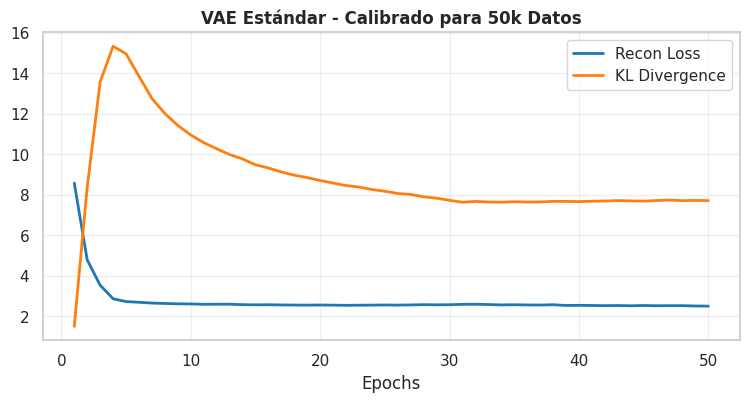

Generando población sintética...
✅ Generados 5000 individuos en escala real con éxito.


=== RESULTADOS DEL EXAMEN (Variables Limitadas) ===
Modelo TSTR (Sintético) -> R²: 0.2792 | MAE: 0.6003
Modelo TRTR (Real)      -> R²: 0.2916 | MAE: 0.5932

Eficiencia de la población sintética: Retiene el 95.8% del poder predictivo.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# MACHINE LEARNING UTILITY TEST (TSTR - ANTI-LEAKAGE)
# =========================================================
print("Iniciando Test TSTR con predicción parcial (Anti-trampas)...")

# TARGET: Predict Tradition (Conservation value)
target_col = 'trms'

# PREDICTORS: Only 3 values (from Openness to Change and Self-Enhancement)
# Using only 3 breaks the zero-sum constraint, avoiding trivial solutions.
features = ['hems', 'stmms', 'poms']

# ==========================================
# STEP 0: CLEAN SPLIT BEFORE VAE TRAINING
# The held-out set is never seen by the evaluation VAE
# ==========================================
X_train_vae, X_held_out = train_test_split(X_raw, test_size=0.2, random_state=42)

# Scaler fitted ONLY on VAE training data
scaler_tstr = StandardScaler()
X_train_scaled = scaler_tstr.fit_transform(X_train_vae)
X_held_out_original = scaler_tstr.inverse_transform(scaler_tstr.fit_transform(X_held_out))

# Reconstruct held-out in ipsatized scale
X_held_out_scaled = scaler_tstr.transform(X_held_out)
X_held_out_original = scaler_tstr.inverse_transform(X_held_out_scaled)
df_held_out = pd.DataFrame(X_held_out_original, columns=cols_ms)

# ==========================================
# STEP 1: TRAIN A CLEAN VAE FOR TSTR ONLY
# ==========================================
print("Entrenando VAE limpio para evaluación TSTR...")
model_tstr, _ = train_vae(X_train_scaled, epochs=50, latent_dim=5)

# ==========================================
# STEP 2: GENERATE SYNTHETIC DATA WITH CLEAN VAE
# ==========================================
df_synt_tstr, _ = generar_poblacion(model_tstr, scaler=scaler_tstr, latent_dim=5, n_eval=5000)

# ==========================================
# STEP 3: TSTR — test set is the held-out that the VAE NEVER saw
# ==========================================
X_real_test = df_held_out[features].values
y_real_test = df_held_out[target_col].values

X_synth_train = df_synt_tstr[features].values
y_synth_train = df_synt_tstr[target_col].values

# For TRTR: use held-out as test and real training data as train
df_train_real = pd.DataFrame(
    scaler_tstr.inverse_transform(X_train_scaled), columns=cols_ms
)
X_real_train = df_train_real[features].values
y_real_train = df_train_real[target_col].values

# ==========================================
# STEP 4: TRAIN REGRESSORS
# ==========================================
reg_synth = Ridge(alpha=1.0)
reg_synth.fit(X_synth_train, y_synth_train)

reg_real = Ridge(alpha=1.0)
reg_real.fit(X_real_train, y_real_train)

# ==========================================
# STEP 5: EVALUATION
# ==========================================
preds_synth = reg_synth.predict(X_real_test)
preds_real = reg_real.predict(X_real_test)

r2_synth = r2_score(y_real_test, preds_synth)
mae_synth = mean_absolute_error(y_real_test, preds_synth)

r2_real = r2_score(y_real_test, preds_real)
mae_real = mean_absolute_error(y_real_test, preds_real)

print("\n=== RESULTADOS DEL EXAMEN (Variables Limitadas) ===")
print(f"Modelo TSTR (Sintético) -> R²: {r2_synth:.4f} | MAE: {mae_synth:.4f}")
print(f"Modelo TRTR (Real)      -> R²: {r2_real:.4f} | MAE: {mae_real:.4f}")

eficiencia_mantenida = (r2_synth / r2_real) * 100 if r2_real > 0 else 0
print(f"\nEficiencia de la población sintética: Retiene el {eficiencia_mantenida:.1f}% del poder predictivo.")